In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore') 

# Data Preprocessing

In [2]:
# 1. Load data
ratings = pd.read_csv("ml-100k/u.data", sep='\t', names=["user_id", "item_id", "rating", "timestamp"])

In [3]:
ratings.shape

(100000, 4)

In [4]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [5]:
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


# Data Visualization

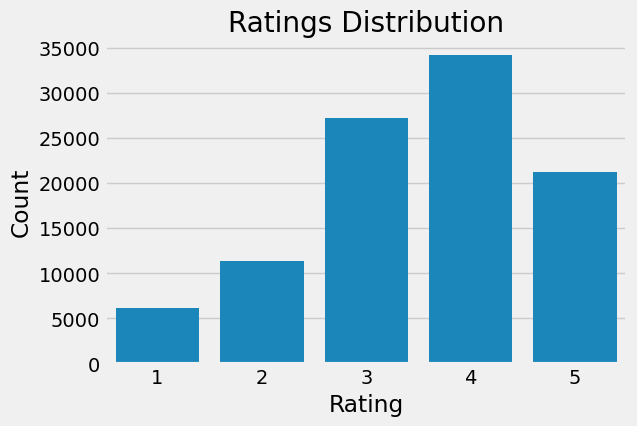

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=ratings)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

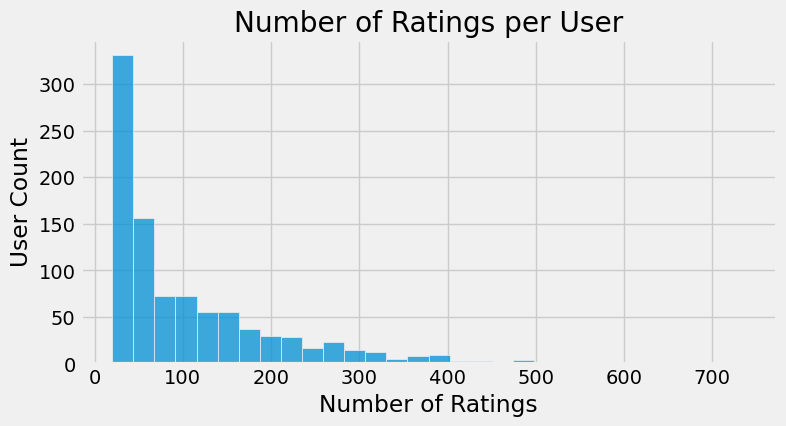

In [7]:
user_rating_counts = ratings.groupby("user_id").size()
plt.figure(figsize=(8,4))
sns.histplot(user_rating_counts, bins=30, kde=False)
plt.title("Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("User Count")
plt.show()

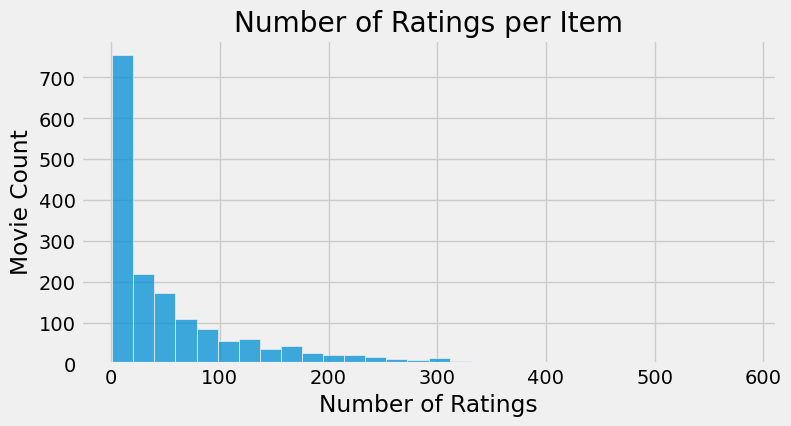

In [8]:
item_rating_counts = ratings.groupby("item_id").size()

plt.figure(figsize=(8,4))
sns.histplot(item_rating_counts, bins=30, kde=False)
plt.title("Number of Ratings per Item")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Count")
plt.show()

# Collaborative Filtering

In [10]:
# 2. Construct the user-item rating matrix
utility_matrix = ratings.pivot_table(index="user_id", columns="item_id", values="rating")

# 3. Calculate the centralized rating matrix (remove the average rating of each user)
centered_matrix = utility_matrix.sub(utility_matrix.mean(axis=1), axis=0)

# 4. Handle missing values to 0 (set positions not involved in similarity calculation to 0)
centered_filled = centered_matrix.fillna(0)

# 5. Calculate the cosine similarity between users
similarity_matrix = cosine_similarity(centered_filled)

# Convert the similarity matrix to a DataFrame for easier operation
similarity_df = pd.DataFrame(similarity_matrix, index=utility_matrix.index, columns=utility_matrix.index)

# 6. Find the top 10 users (excluding yourself) who are most similar to User 1
top_10_similar_users = similarity_df.loc[1].drop(index=1).nlargest(10).index.tolist()

# 7. Obtain the ratings of these users for item 508
item_id = 508
ratings_for_item_508 = utility_matrix.loc[top_10_similar_users, item_id]

# 8. Calculate the average rating of item 508 by these similar users (ignoring missing values)
expected_rating = ratings_for_item_508.mean()

# Output Result
print("The top 10 similar users of User 1:", top_10_similar_users)
print(f"The ratings of item 508 by these similar users:\n{ratings_for_item_508}")
print(f"Based on similar users, the predicted rating of item 508 by user 1 is: {expected_rating:.2f}")

The top 10 similar users of User 1: [773, 868, 592, 880, 429, 276, 916, 222, 457, 8]
The ratings of item 508 by these similar users:
user_id
773    NaN
868    NaN
592    5.0
880    4.0
429    4.0
276    5.0
916    NaN
222    3.0
457    NaN
8      NaN
Name: 508, dtype: float64
Based on similar users, the predicted rating of item 508 by user 1 is: 4.20


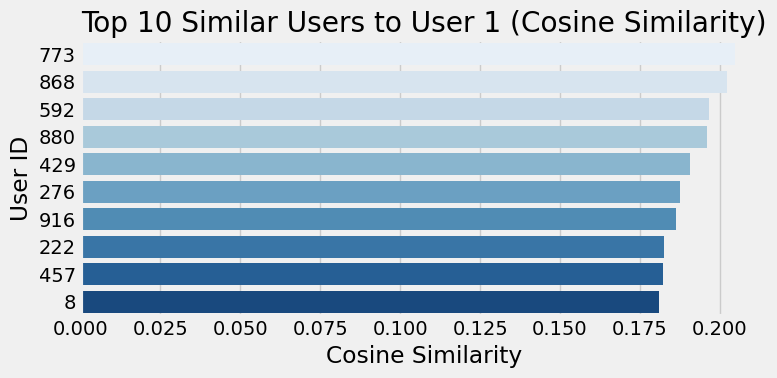

In [13]:
user_1_similarities = similarity_df.loc[1].drop(1).nlargest(10)
plt.figure(figsize=(8, 4))
sns.barplot(x=user_1_similarities.values, y=user_1_similarities.index.astype(str), palette="Blues")
plt.title("Top 10 Similar Users to User 1 (Cosine Similarity)")
plt.xlabel("Cosine Similarity")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

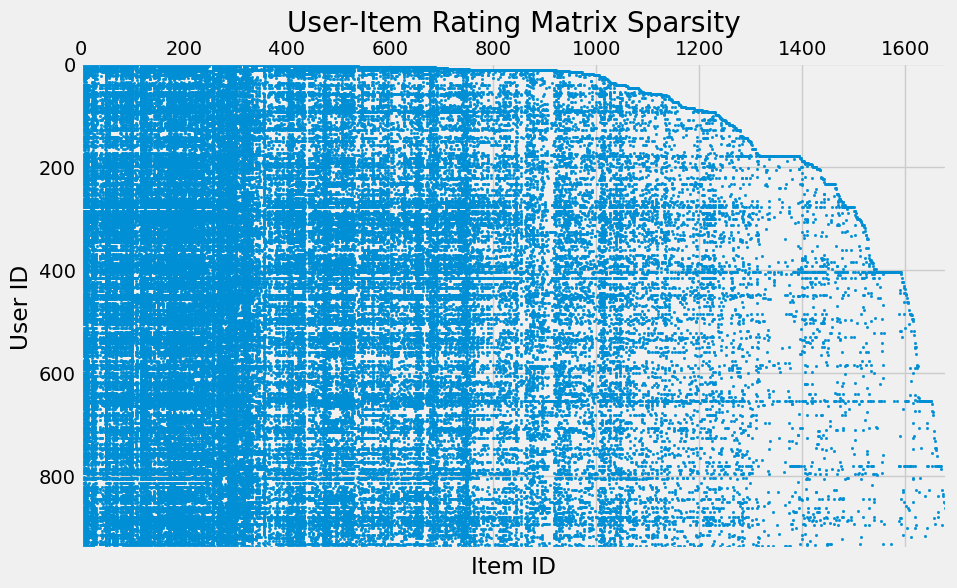

In [11]:
plt.figure(figsize=(10,6))
plt.spy(utility_matrix.notnull(), markersize=1)
plt.title("User-Item Rating Matrix Sparsity")
plt.xlabel("Item ID")
plt.ylabel("User ID")
plt.show()

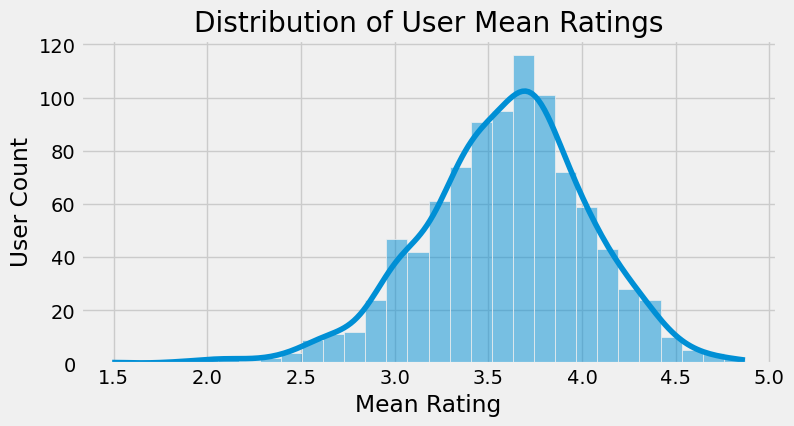

In [12]:
user_means = utility_matrix.mean(axis=1)
plt.figure(figsize=(8,4))
sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of User Mean Ratings")
plt.xlabel("Mean Rating")
plt.ylabel("User Count")
plt.show()

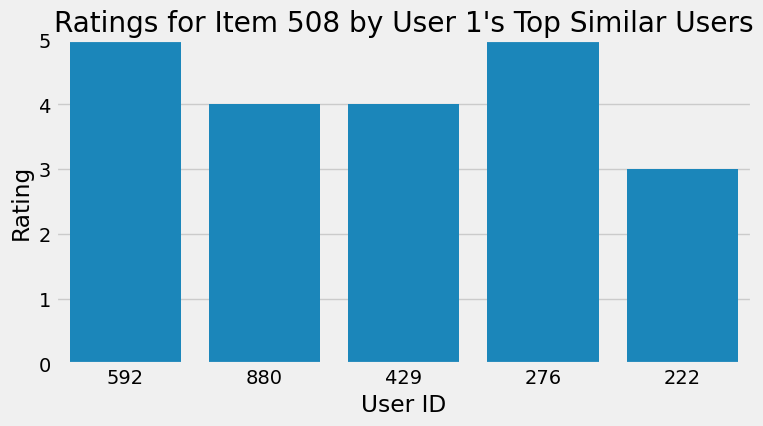

In [14]:
valid_ratings = ratings_for_item_508.dropna()
plt.figure(figsize=(8, 4))
sns.barplot(x=valid_ratings.index.astype(str), y=valid_ratings.values)
plt.title("Ratings for Item 508 by User 1's Top Similar Users")
plt.xlabel("User ID")
plt.ylabel("Rating")
plt.ylim(0, 5)
plt.show()